# Lausanne Rivers and Lakeshore Statistics

This notebook
- discovers river and lake files in `./data/`
- computes river lengths by year
- computes pairwise river loss statistics
- computes lakeshore displacement
- prints summary tables
- saves CSV outputs
- plots river lengths over time

In [34]:
# Imports

import os
import re
import unicodedata
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

In [ ]:
# Configuration

DATA_FOLDER = os.path.join(".", "data")
TARGET_EPSG = 2056

LEGACY_NAMES = {
    "berney": 1831,
    "renove": 1888,
    "contemporain": 2021,
}

POSSIBLE_NAME_COLUMNS = [
    "name",
    "nom",
    "riviere",
    "nom_riviere",
    "river_name",
    "nom_riv",
    "Name_1",
]

RIVERS_TO_DROP = ["inconnu", "unknown", "temp_name_col"]

In [36]:
# Helper functions

def normalize_river_name(name):
    """Clean and standardize river names to group them correctly."""
    if not isinstance(name, str):
        return "inconnu"

    name = name.lower().strip()
    name = "".join(
        c for c in unicodedata.normalize("NFD", name)
        if unicodedata.category(c) != "Mn"
    )

    corrections = {
        "la vuachere": "vuachere",
        "vuachere+riolet": "vuachere",
        "le flon": "flon",
        "la louve": "louve",
        "unknown": "inconnu",
        "le petit flon": "petitflon",
    }

    return corrections.get(name, name)


def find_year_from_filename(filename, legacy_names):
    """Extract year from filename or map a legacy alias to a year."""
    match = re.search(r"\d{4}", filename)
    if match:
        return int(match.group())

    filename_lower = filename.lower()
    for key, value in legacy_names.items():
        if key in filename_lower:
            return value

    return None


def discover_time_periods(data_folder, legacy_names):
    """Discover available river and lake files grouped by year."""
    if not os.path.exists(data_folder):
        raise FileNotFoundError(
            f"Could not find the folder '{data_folder}'. Please create it and add your files."
        )

    time_periods = {}

    for filename in os.listdir(data_folder):
        if not filename.endswith((".gpkg", ".shp", ".geojson")):
            continue

        filepath = os.path.join(data_folder, filename)
        filename_lower = filename.lower()
        year = find_year_from_filename(filename, legacy_names)

        if not year:
            continue

        if year not in time_periods:
            time_periods[year] = {}

        if "river" in filename_lower or "riviere" in filename_lower:
            time_periods[year]["river"] = filepath
            print(f"Detected River data for {year}: {filename}")
        elif "lake" in filename_lower or "lac" in filename_lower or "shore" in filename_lower:
            time_periods[year]["lake"] = filepath
            print(f"Detected Lake data for {year}: {filename}")

    return time_periods


def find_name_column(gdf, possible_name_columns):
    """Find the first matching river-name column."""
    for col in gdf.columns:
        if col.lower() in possible_name_columns:
            return col
    return None


def inspect_layer(filepath, possible_name_columns):
    gdf = gpd.read_file(filepath)
    name_col = find_name_column(gdf, possible_name_columns)
    return {
        "filepath": filepath,
        "rows": len(gdf),
        "columns": ", ".join(gdf.columns.astype(str)),
        "crs": str(gdf.crs),
        "geometry_types": ", ".join(gdf.geom_type.value_counts().index.astype(str)),
        "name_column": name_col,
        "missing_name_values": int(gdf[name_col].isna().sum()) if name_col else None,
    }


def load_river_data_for_year(filepath, year, possible_name_columns):
    """Load one river layer, compute lengths, and aggregate by cleaned river name."""
    gdf = gpd.read_file(filepath).to_crs(epsg=TARGET_EPSG)
    gdf["length_m"] = gdf.geometry.length

    col_name = find_name_column(gdf, possible_name_columns)
    if not col_name:
        col_name = "temp_name_col"
        gdf[col_name] = "unknown"

    gdf["clean_name"] = gdf[col_name].apply(normalize_river_name)

    summed = gdf.groupby("clean_name")["length_m"].sum().reset_index()
    summed.rename(columns={"clean_name": "river_name"}, inplace=True)
    summed["year"] = year
    return gdf, summed, col_name


def build_river_statistics(years, time_periods, possible_name_columns):
    """Compute river statistics table from all available river layers."""
    river_data = []
    river_layers = {}

    for year in years:
        if "river" not in time_periods[year]:
            print(f"No river data found for {year}. Skipping...")
            continue

        gdf, summed, col_name = load_river_data_for_year(
            time_periods[year]["river"],
            year,
            possible_name_columns,
        )
        river_layers[year] = {
            "gdf": gdf,
            "name_col": col_name,
        }
        river_data.append(summed)

    if not river_data:
        return river_data, None, None, river_layers

    df_rivers = pd.concat(river_data, ignore_index=True)
    pivot_rivers = df_rivers.pivot(index="river_name", columns="year", values="length_m")

    available_river_years = sorted(df_rivers["year"].unique())
    for i in range(len(available_river_years) - 1):
        y1, y2 = available_river_years[i], available_river_years[i + 1]
        time_gap = y2 - y1

        pivot_rivers[f"Lost_m_{y1}_to_{y2}"] = pivot_rivers[y1] - pivot_rivers[y2]

        pivot_rivers[f"Loss_%_{y1}_to_{y2}"] = np.where(
            (pivot_rivers[y1] > 0) & pivot_rivers[y1].notna() & pivot_rivers[y2].notna(),
            (pivot_rivers[f"Lost_m_{y1}_to_{y2}"] / pivot_rivers[y1]) * 100,
            np.nan,
        )

        pivot_rivers[f"Rate_m_per_yr_{y1}_to_{y2}"] = (
            pivot_rivers[f"Lost_m_{y1}_to_{y2}"] / time_gap
        )

    return river_data, df_rivers, pivot_rivers, river_layers


def build_lake_statistics(years, time_periods):
    """Compute pairwise displacement for lakeshore layers."""
    lake_gdfs = {}
    for year in years:
        if "lake" in time_periods[year]:
            gdf = gpd.read_file(time_periods[year]["lake"]).to_crs(epsg=TARGET_EPSG)
            lake_gdfs[year] = gdf.geometry.union_all()

    lake_stats = []
    available_lake_years = sorted(lake_gdfs.keys())

    if len(available_lake_years) > 1:
        for i in range(len(available_lake_years) - 1):
            y1, y2 = available_lake_years[i], available_lake_years[i + 1]
            max_dist = lake_gdfs[y1].hausdorff_distance(lake_gdfs[y2])

            lake_stats.append({
                "Period": f"{y1} to {y2}",
                "Max_Displacement_m": max_dist,
            })

        start_y, end_y = available_lake_years[0], available_lake_years[-1]
        total_dist = lake_gdfs[start_y].hausdorff_distance(lake_gdfs[end_y])

        lake_stats.append({
            "Period": f"TOTAL ({start_y} to {end_y})",
            "Max_Displacement_m": total_dist,
        })

    df_lake = pd.DataFrame(lake_stats) if lake_stats else None
    return lake_stats, df_lake


def prepare_clean_river_table(pivot_rivers, years, rivers_to_drop):
    """Prepare the display table used in the original notebook."""
    clean_river_table = pivot_rivers[years].round(0).astype("Int64")

    for drop_name in rivers_to_drop:
        if drop_name in clean_river_table.index:
            clean_river_table = clean_river_table.drop(drop_name)

    return clean_river_table


def save_outputs(pivot_rivers=None, df_lake=None):
    """Save CSV outputs matching the original notebook behavior."""
    if pivot_rivers is not None:
        pivot_rivers.round(2).to_csv("river_statistics.csv")

    if df_lake is not None:
        print("Saving lakeshore_statistics.csv...")
        df_lake.round(2).to_csv("lakeshore_statistics.csv", index=False)


def print_outputs(river_data, clean_river_table, lake_stats, df_lake):
    """Print summary tables matching the original notebook behavior."""
    print("\n=== RIVER LENGTHS BY YEAR (Meters) ===")
    if river_data:
        print(clean_river_table.to_string(na_rep="<NA>"))
    else:
        print("No river data to display.")

    print("\n=== LAKESHORE DISPLACEMENT ===")
    if lake_stats:
        print(df_lake.to_string(index=False))
    else:
        print("No lakeshore data to display.")


def plot_river_lengths(river_data, clean_river_table):
    """Plot river-length evolution matching the original notebook behavior."""
    if not river_data:
        return

    plt.figure(figsize=(12, 7))

    for river in clean_river_table.index:
        row = clean_river_table.loc[river].dropna()
        if not row.empty:
            plt.plot(
                row.index.astype(str),
                row.values,
                marker="o",
                linewidth=2,
                label=river.title(),
            )

    plt.title(
        "Development of Individual Rivers in Lausanne (1831 - 2021)",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Length in Open Air (meters)", fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()


def plot_river_maps(river_layers):
    if not river_layers:
        print("No river layers available for plotting.")
        return

    years = sorted(river_layers.keys())
    n = len(years)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 6), squeeze=False)

    for ax, year in zip(axes[0], years):
        gdf = river_layers[year]["gdf"]
        gdf.plot(ax=ax, linewidth=1)
        ax.set_title(f"Rivers {year}")
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()


def build_inventory_table(time_periods, possible_name_columns):
    rows = []
    for year in sorted(time_periods.keys()):
        for data_type in ["river", "lake"]:
            if data_type in time_periods[year]:
                info = inspect_layer(time_periods[year][data_type], possible_name_columns)
                rows.append({
                    "year": year,
                    "type": data_type,
                    **info,
                })
    return pd.DataFrame(rows)


def preview_river_names(river_layers, max_names=20):
    rows = []
    for year, payload in sorted(river_layers.items()):
        gdf = payload["gdf"]
        name_col = payload["name_col"]
        if name_col and name_col in gdf.columns:
            unique_names = (
                gdf[name_col]
                .dropna()
                .astype(str)
                .str.strip()
                .unique()
                .tolist()
            )
            rows.append({
                "year": year,
                "name_column": name_col,
                "unique_name_count": len(unique_names),
                "sample_names": ", ".join(unique_names[:max_names]),
            })
        else:
            rows.append({
                "year": year,
                "name_column": None,
                "unique_name_count": 0,
                "sample_names": "",
            })
    return pd.DataFrame(rows)

In [37]:
# Discover files

time_periods = discover_time_periods(DATA_FOLDER, LEGACY_NAMES)
years = sorted(time_periods.keys())
print(f"\nChronology established: {years}\n")

Detected River data for 1831: berney_rivers.gpkg
Detected River data for 2021: contemporain_rivers.gpkg
Detected Lake data for 1831: berney_lake.gpkg
Detected Lake data for 2021: contemporain_lake.gpkg
Detected River data for 1959: 1959_rivers.gpkg
Detected River data for 1888: renove_river.gpkg
Detected Lake data for 1888: renove_lake.gpkg
Detected Lake data for 1959: 1959_lake.gpkg

Chronology established: [1831, 1888, 1959, 2021]



In [38]:
# File inventory

inventory_df = build_inventory_table(time_periods, POSSIBLE_NAME_COLUMNS)
display(inventory_df)

,year,type,filepath,rows,columns,crs,geometry_types,name_column,missing_name_values
0,1831,river,./data/berney_rivers.gpkg,24,"id, name, length, geometry",EPSG:2056,MultiLineString,name,0.0
1,1831,lake,./data/berney_lake.gpkg,1,"id, geometry",EPSG:2056,MultiLineString,None,NaN
2,1888,river,./data/renove_river.gpkg,35,"id, length, name, geometry",EPSG:2056,MultiLineString,name,8.0
3,1888,lake,./data/renove_lake.gpkg,1,"id, geometry",EPSG:2056,MultiLineString,None,NaN
4,1959,river,./data/1959_rivers.gpkg,16,"id, name, Name_1, length, geometry",EPSG:2056,MultiLineString,name,0.0
5,1959,lake,./data/1959_lake.gpkg,3,"id, name, Name_1, length, geometry",EPSG:2056,MultiLineString,name,0.0
6,2021,river,./data/contemporain_rivers.gpkg,24,"osm_id, name, type, width, length, geometry",EPSG:4326,MultiLineString,name,2.0
7,2021,lake,./data/contemporain_lake.gpkg,1,"id, length, geometry",EPSG:2056,MultiLineString,None,NaN


In [39]:
# River statistics

river_data, df_rivers, pivot_rivers, river_layers = build_river_statistics(
    years=years,
    time_periods=time_periods,
    possible_name_columns=POSSIBLE_NAME_COLUMNS,
)

In [44]:
## Preview river names by year

if river_layers:
    river_name_preview = preview_river_names(river_layers)
    pd.set_option('display.max_colwidth', None)
    display(river_name_preview)
else:
    print("No river layers available.")

,year,name_column,unique_name_count,sample_names
0,1831,name,8,"flon, louve, vuachère, boveresses, vuachère+riolet, inconnu, galicien, petitflon"
1,1888,name,4,"Vuachère, Flon, Louve, Boveresses"
2,1959,name,4,"La Vuachere, Le Flon, Le petit Flon, La Louve"
3,2021,name,5,"La Vuachère, La Louve, Le Flon, Le Petit Flon, Le Rionzi"


In [45]:
# Lakeshore statistics

lake_stats, df_lake = build_lake_statistics(
    years=years,
    time_periods=time_periods,
)

In [46]:
# Save outputs

save_outputs(
    pivot_rivers=pivot_rivers,
    df_lake=df_lake,
)

Saving lakeshore_statistics.csv...


In [47]:
# Prepare display table

if river_data:
    clean_river_table = prepare_clean_river_table(
        pivot_rivers=pivot_rivers,
        years=years,
        rivers_to_drop=RIVERS_TO_DROP,
    )
else:
    clean_river_table = None

print_outputs(
    river_data=river_data,
    clean_river_table=clean_river_table,
    lake_stats=lake_stats,
    df_lake=df_lake,
)


=== RIVER LENGTHS BY YEAR (Meters) ===
year        1831  1888  1959  2021
river_name                        
boveresses   765   767  <NA>  <NA>
flon        5898  5491   104   116
galicien      28  <NA>  <NA>  <NA>
le rionzi   <NA>  <NA>  <NA>   210
louve       2321  1501   446   339
petitflon    603  <NA>   652   686
vuachere    3313  3372  2756  2793

=== LAKESHORE DISPLACEMENT ===
              Period  Max_Displacement_m
        1831 to 1888          162.769517
        1888 to 1959          156.410671
        1959 to 2021          254.756952
TOTAL (1831 to 2021)          290.367079


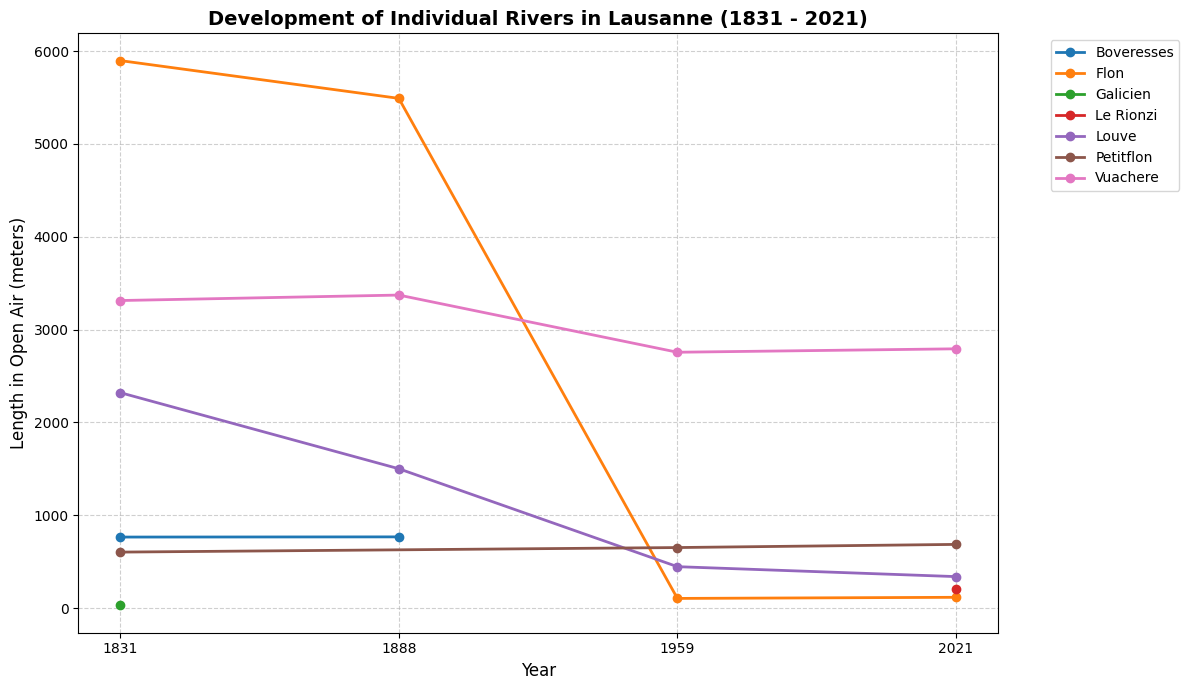

In [48]:
# Plot river lengths

plot_river_lengths(
    river_data=river_data,
    clean_river_table=clean_river_table,
)

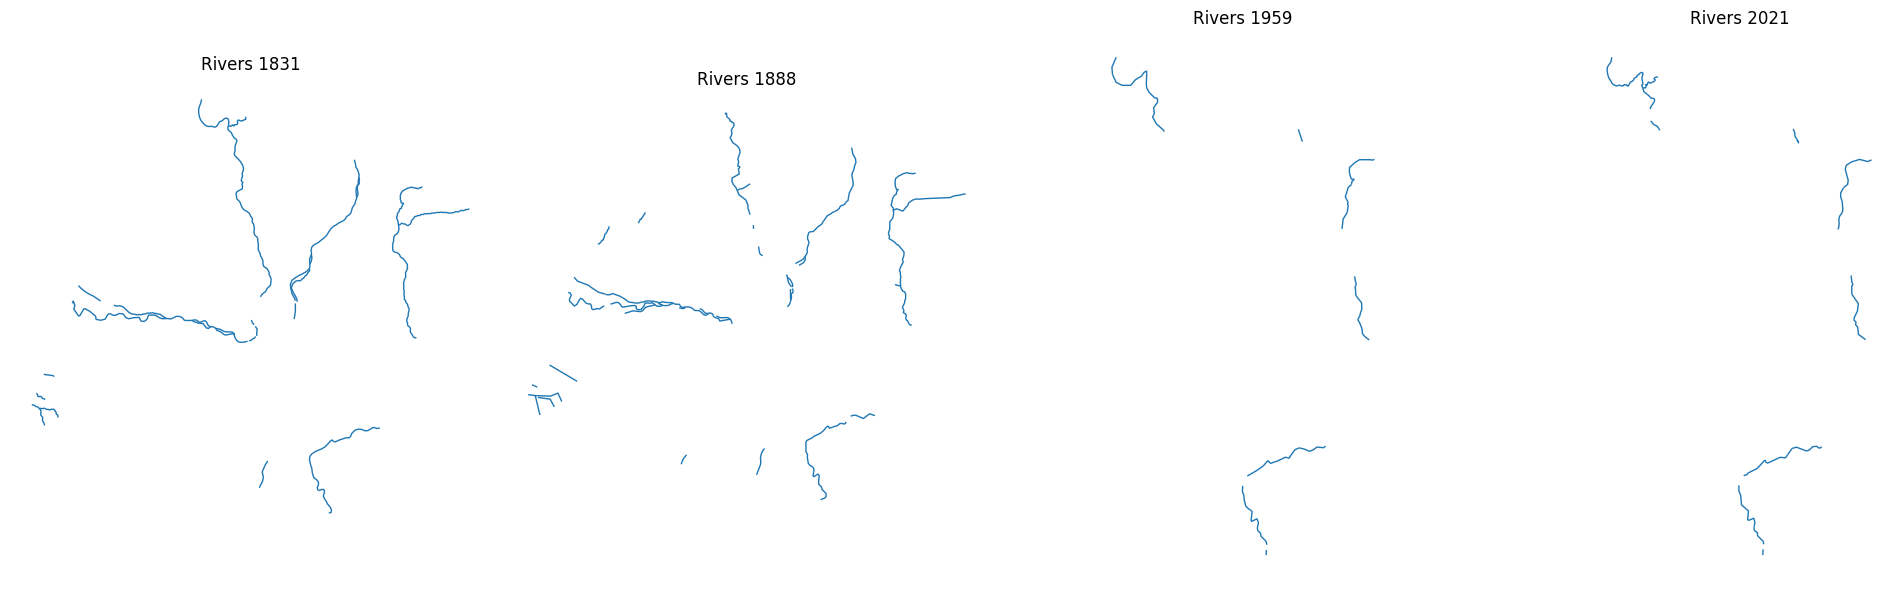

In [50]:
# Plot rivers by year

plot_river_maps(river_layers)